In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import seaborn as sns
from mpralib.mpradata import MPRABarcodeData
from mpralib.mpradata import Modality
from mpralib.utils.plot import dna_vs_rna, barcodes_per_oligo
from mpralib.utils.plot import correlation
from mpralib.mpradata import BarcodeFilter
from scipy.stats import spearmanr, pearsonr

import scripts.element_analysis as element_analysis
import scripts.quality_control as quality_control
import scripts.plotting as plotting

#### Create a label data frame

In [2]:
df_label = pd.read_table('data/mpra_80k_seq_label.tsv.gz', 
                         header=None, 
                         names=["oligo_name", "label"])

In [3]:
df_label["label"].unique()
df_label["label"].value_counts()

label
cardiac_neuro_cava_random            73940
MK                                    1897
C_positive_heart_AB                    909
scramble_ctrl                          500
negative_neuron_ctrl                   451
GC_Selvarajan                          358
GC_Vista                               256
C_negative_heart_MK                    231
GC_Mendelian_variants                  209
GC_Kircher                             203
C_SLEA                                 200
GC_Cort_Chengyu                        185
C_positive_heart_CAD                    99
C_positive_neuron_NP                    99
C_positive_heart_MK                     97
C_positive_neuron_MK                    96
C_positive_neuron_CD                    94
GC_Glut_Chengyu                         83
GC_DNase_positive_shuffeled             55
GC_Atrial_fib                           45
GC_GABA_Chengyu                         42
GC_DNase_positive                       41
GC_Mohlke                               38
GC_DN

### MPRA Report label annotation

In [4]:
input_snakeflow_files = { 
    'NGN2': 'data/reporter_experiment.barcode.NGN2.bbmapMapq30StrandSensitiveAssignment.default.all.tsv.gz',
    'WTC11':  'data/reporter_experiment.barcode.WTC11.bbmapMapq30StrandSensitiveAssignment.default.all.tsv.gz'                    }

In [5]:
grouped_data = element_analysis.group_cells_to_oligo(input_snakeflow_files = input_snakeflow_files)

In [6]:
grouped_data['NGN2'].head()

,oligo_name,dna_count_1,rna_count_1,dna_count_2,rna_count_2,dna_count_3,rna_count_3,unique_barcode_count
0,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,537.0,1536.0,509.0,1465.0,538.0,1567.0,151
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,478.0,3122.0,559.0,2489.0,597.0,3020.0,131
2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,334.0,1009.0,294.0,1005.0,336.0,966.0,99
3,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,400.0,1356.0,467.0,1328.0,497.0,1301.0,121
4,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,261.0,841.0,269.0,816.0,300.0,855.0,68


#### Mapping labels to oligo names

#### Map the label data to oligo

In [7]:
grouped_data = element_analysis.mapping(grouped_data = grouped_data,
                                        mapping_data = df_label,
                                        on = 'oligo_name',
                                        element = 'label',
                                        output_column = 'label')

In [8]:
grouped_data['WTC11'].head()

,oligo_name,dna_count_1,rna_count_1,dna_count_2,rna_count_2,dna_count_3,rna_count_3,unique_barcode_count,label
0,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,941.0,1938.0,965.0,2189.0,755.0,2279.0,141,C_SLEA
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,870.0,2290.0,852.0,2451.0,671.0,2540.0,121,C_SLEA
2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,493.0,1041.0,448.0,1162.0,494.0,1136.0,87,C_SLEA
3,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,769.0,1713.0,898.0,2027.0,700.0,2070.0,120,C_SLEA
4,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,371.0,1001.0,478.0,1065.0,440.0,1184.0,64,C_SLEA


# Comparison of the effect size between NGN2 and WCT11

In [9]:
input_bcalme_files = {
    'NGN2': 'data/results/elements/cli_NGN2_202511_80k_element_bbmap_bcalm_normalized_bc10_toptreat_results_scrambled_NP_MK_result_095_dev.tsv',
    'WTC11': 'data/results/elements/cli_WTC11_202511_80k_element_bbmap_bcalm_normalized_bc10_toptreat_results_scrambled_NP_MK_result_095_dev.tsv'

}

#### Mapping the effect size to the oligo names, for NGN2 and WTC11 with barcode threshold 10 and 1


In [10]:
grouped_data = element_analysis.map_column_from_files(grouped_data = grouped_data,
                                                      files= input_bcalme_files,
                                                      on = 'name',
                                                      element = 'logFC',
                                                      output_column = 'effect_size')

In [11]:
grouped_data['NGN2'].head()

,oligo_name,dna_count_1,rna_count_1,dna_count_2,rna_count_2,dna_count_3,rna_count_3,unique_barcode_count,label,effect_size
0,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,537.0,1536.0,509.0,1465.0,538.0,1567.0,151,C_SLEA,0.009842
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,478.0,3122.0,559.0,2489.0,597.0,3020.0,131,C_SLEA,0.891777
2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,334.0,1009.0,294.0,1005.0,336.0,966.0,99,C_SLEA,0.092969
3,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,400.0,1356.0,467.0,1328.0,497.0,1301.0,121,C_SLEA,0.024602
4,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,261.0,841.0,269.0,816.0,300.0,855.0,68,C_SLEA,0.092226


#### Get scrambled sequences and compute mean and standard deviation, for NGN2 and WTC11 with barcode threshold 10 and 1

#### Create column with the normalized effect size by using the mean and sd of the scramble_ctrl label data, for NGN2 and WTC11 with barcode threshold 10 and 1

In [12]:
normalized_data = element_analysis.calculate_normalized_values(grouped_data = grouped_data)

In [13]:
normalized_data['NGN2'][normalized_data['NGN2']['norm_effect_size']>0].head()

,oligo_name,dna_count_1,rna_count_1,dna_count_2,rna_count_2,dna_count_3,rna_count_3,unique_barcode_count,label,effect_size,norm_effect_size
0,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,537.0,1536.0,509.0,1465.0,538.0,1567.0,151,C_SLEA,0.009842,0.510769
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,478.0,3122.0,559.0,2489.0,597.0,3020.0,131,C_SLEA,0.891777,2.753048
2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,334.0,1009.0,294.0,1005.0,336.0,966.0,99,C_SLEA,0.092969,0.722116
3,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,400.0,1356.0,467.0,1328.0,497.0,1301.0,121,C_SLEA,0.024602,0.548297
4,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,261.0,841.0,269.0,816.0,300.0,855.0,68,C_SLEA,0.092226,0.720226


### Important Mapping the adjusted p-value to the oligo names, for NGN2 and WTC11 with barcode threshold 10 and 1

In [14]:
normalized_mapped_data = element_analysis.map_column_from_files(grouped_data = normalized_data,
                                                         files = input_bcalme_files,
                                                         on = 'name',
                                                         element = 'adj.P.Val',
                                                         output_column = 'adj.P.Val')

In [15]:
normalized_mapped_data['WTC11'].head()

,oligo_name,dna_count_1,rna_count_1,dna_count_2,rna_count_2,dna_count_3,rna_count_3,unique_barcode_count,label,effect_size,norm_effect_size,adj.P.Val
0,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,941.0,1938.0,965.0,2189.0,755.0,2279.0,141,C_SLEA,0.193683,0.630077,1.0
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,870.0,2290.0,852.0,2451.0,671.0,2540.0,121,C_SLEA,0.453775,1.340039,1.0
2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,493.0,1041.0,448.0,1162.0,494.0,1136.0,87,C_SLEA,-0.093951,-0.155068,1.0
3,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,769.0,1713.0,898.0,2027.0,700.0,2070.0,120,C_SLEA,0.012860,0.136489,1.0
4,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,371.0,1001.0,478.0,1065.0,440.0,1184.0,64,C_SLEA,0.252162,0.789705,1.0


#### compare the data with missing entries (in this example with effect_size)

In [16]:
missing_entries = quality_control.count_missing_values(grouped_data = normalized_mapped_data,
                                        column = 'effect_size')

In [17]:
missing_entries

{'NGN2': 'total rows:77945 | missing data:7466',
 'WTC11': 'total rows:77871 | missing data:24110'}

In [18]:
missing_entry_percent = quality_control.missing_values_in_percent(grouped_data=normalized_mapped_data,
                                           column = 'effect_size')

In [19]:
missing_entry_percent

{'NGN2': '9.58% of the effect_size column are missing',
 'WTC11': '30.96% of the effect_size column are missing'}

WTC11 with barcode threshold 10 has a substantially higher proportion of missing effect-size values than NGN2 (30.96% vs. 9.58%)

### Analyze the WTC11/NGN2 data with missing and non missing effectsize with a special focus on WTC11

In [ ]:
missing_data = quality_control.filter_missing_values(grouped_data = normalized_mapped_data,
                                        column = 'effect_size')
present_data = quality_control.drop_missing_values(grouped_data = normalized_mapped_data,
                                        column = 'effect_size')

In [42]:
len(missing_data['NGN2']), len(present_data['NGN2'])

(7466, 70479)

In [22]:
missing_data['WTC11'].head()

,oligo_name,dna_count_1,rna_count_1,dna_count_2,rna_count_2,dna_count_3,rna_count_3,unique_barcode_count,label,effect_size,norm_effect_size,adj.P.Val
28,C_SLEA:SLEA_hg18:chr2:210861483-210861650|18:V...,20.0,52.0,12.0,34.0,18.0,55.0,2,C_SLEA,NaN,NaN,NaN
30,C_SLEA:SLEA_hg18:chr2:210861483-210861650|19:V...,14.0,38.0,26.0,75.0,9.0,40.0,1,C_SLEA,NaN,NaN,NaN
31,C_SLEA:SLEA_hg18:chr2:210861483-210861650|20:V...,43.0,69.0,86.0,179.0,35.0,160.0,6,C_SLEA,NaN,NaN,NaN
39,C_SLEA:SLEA_hg18:chr2:210861483-210861650|22:V...,155.0,307.0,189.0,355.0,132.0,339.0,24,C_SLEA,NaN,NaN,NaN
44,C_SLEA:SLEA_hg18:chr2:210861483-210861650|25:V...,14.0,38.0,22.0,121.0,40.0,73.0,6,C_SLEA,NaN,NaN,NaN


### Merge NGN2 and WTC11 tabels with all entries and filter only with the on thier are in all cells

#### Barcode threshold 10

In [52]:
merged_all_data = element_analysis.merge_cell_type_tables(
    grouped_data = normalized_mapped_data,
    how = 'outer',
    on = 'oligo_name')

In [51]:
merge_shared_data = element_analysis.merge_cell_type_tables(
    grouped_data = filtered_data,
    how = 'inner',
    on = 'oligo_name')

In [29]:
normalized_mapped_data['NGN2'].columns

Index(['oligo_name', 'dna_count_1', 'rna_count_1', 'dna_count_2',
       'rna_count_2', 'dna_count_3', 'rna_count_3', 'unique_barcode_count',
       'label', 'effect_size', 'norm_effect_size', 'adj.P.Val'],
      dtype='object')

In [44]:
len(present_data['NGN2']), len(normalized_mapped_data['NGN2'])

(70479, 77945)

In [54]:
compared_effect_size = quality_control.calculate_retained_percentage(grouped_data = present_data,
                                           merge_shared_data = merge_shared_data)

In [55]:
compared_effect_size

{'NGN2': 'Percentage of NGN2 rows retained after merging: 76.278%',
 'WTC11': 'Percentage of WTC11 rows retained after merging: 99.998%'}

### Barcode threshold 10 !!!!!!!!!!!!!!!!!!!!!!!!

#### Comparing the unique oligos per cell type with the merged data table

### Venn diagram to show the overlapping effect size

In [63]:
import importlib
importlib.reload(element_analysis)
importlib.reload(quality_control)
importlib.reload(plotting)

<module 'scripts.plotting' from '/home/adrian/Schreibtisch/MPRA/Bcalm/scripts/plotting.py'>

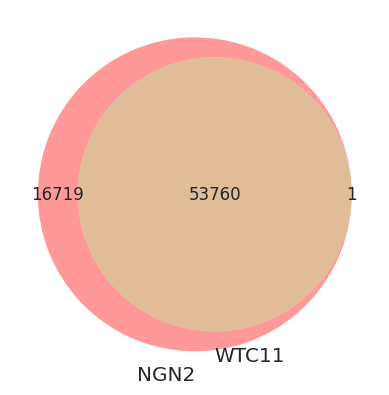

In [64]:
plotting.plot_venn(grouped_data = filtered_data)

#### Effect size with all labels for the NGN2 and WTC11 cells

In [ ]:
def reshape_cell_type_data

In [ ]:
NGN2_WTC11_effect_size_distribution = NGN2_WTC11_merge.melt(
    id_vars = 'oligo_name',
    value_vars = ['norm_effect_size_NGN2', 'norm_effect_size_WTC11'],
    var_name = 'celltype',
    value_name = 'effect_size'
)

NGN2_WTC11_effect_size_distribution.loc[NGN2_WTC11_effect_size_distribution['celltype'].str.contains('NGN2'), 'celltype'] = 'NGN2'
NGN2_WTC11_effect_size_distribution.loc[NGN2_WTC11_effect_size_distribution['celltype'].str.contains('WTC11'), 'celltype'] = 'WTC11'

#### Save the element data for comparison with the variant data

In [ ]:
NGN2_WTC11_merge.to_csv('data/results/merge_elements/element_merge.tsv',
                        sep = '\t',
                        index = False)

Plotting barcode distribution

In [ ]:
NGN2_WTC11_merge

,oligo_name,dna_count_1_NGN2,dna_count_2_NGN2,dna_count_3_NGN2,rna_count_1_NGN2,rna_count_2_NGN2,rna_count_3_NGN2,unique_barcode_count_NGN2,effect_size_NGN2,norm_effect_size_NGN2,...,dna_count_2_WTC11,dna_count_3_WTC11,rna_count_1_WTC11,rna_count_2_WTC11,rna_count_3_WTC11,unique_barcode_count_WTC11,label,effect_size_WTC11,norm_effect_size_WTC11,adj.P.Value_WTC11
0,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,537.0,509.0,538.0,1536.0,1465.0,1567.0,151,0.009842,0.510769,...,965.0,755.0,1938.0,2189.0,2279.0,141,C_SLEA,0.193683,0.630077,1.0
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,478.0,559.0,597.0,3122.0,2489.0,3020.0,131,0.891777,2.753048,...,852.0,671.0,2290.0,2451.0,2540.0,121,C_SLEA,0.453775,1.340039,1.0
2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,334.0,294.0,336.0,1009.0,1005.0,966.0,99,0.092969,0.722116,...,448.0,494.0,1041.0,1162.0,1136.0,87,C_SLEA,-0.093951,-0.155068,1.0
3,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,400.0,467.0,497.0,1356.0,1328.0,1301.0,121,0.024602,0.548297,...,898.0,700.0,1713.0,2027.0,2070.0,120,C_SLEA,0.012860,0.136489,1.0
4,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,261.0,269.0,300.0,841.0,816.0,855.0,68,0.092226,0.720226,...,478.0,440.0,1001.0,1065.0,1184.0,64,C_SLEA,0.252162,0.789705,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53755,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,334.0,318.0,345.0,920.0,969.0,877.0,105,-0.032915,0.402061,...,558.0,397.0,957.0,1183.0,1231.0,89,cardiac_neuro_cava_random,0.152485,0.517619,1.0
53756,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,200.0,178.0,193.0,586.0,581.0,561.0,56,-0.012162,0.454826,...,249.0,361.0,882.0,791.0,947.0,52,cardiac_neuro_cava_random,0.320574,0.976447,1.0
53757,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,300.0,334.0,315.0,1890.0,1504.0,1839.0,115,0.969816,2.951458,...,570.0,404.0,864.0,1157.0,1096.0,101,cardiac_neuro_cava_random,-0.278136,-0.657831,1.0
53758,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,97.0,79.0,112.0,389.0,358.0,390.0,38,0.617933,2.056813,...,157.0,217.0,277.0,377.0,515.0,30,cardiac_neuro_cava_random,0.181087,0.595692,1.0


In [ ]:
NGN2_WTC11_merge["effect_size_NGN2"].isna().sum()

np.int64(0)

In [ ]:
NGN2_WTC11_barcode_count_distribution = NGN2_WTC11_merge.melt(
    id_vars = 'oligo_name',
    value_vars = ['unique_barcode_count_NGN2', 'unique_barcode_count_WTC11'],
    var_name = 'celltype',
    value_name = 'barcode_count'
)
NGN2_WTC11_barcode_count_distribution

,oligo_name,celltype,barcode_count
0,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,unique_barcode_count_NGN2,151
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,unique_barcode_count_NGN2,131
2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,unique_barcode_count_NGN2,99
3,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,unique_barcode_count_NGN2,121
4,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,unique_barcode_count_NGN2,68
...,...,...,...
107515,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,unique_barcode_count_WTC11,89
107516,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,unique_barcode_count_WTC11,52
107517,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,unique_barcode_count_WTC11,101
107518,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,unique_barcode_count_WTC11,30


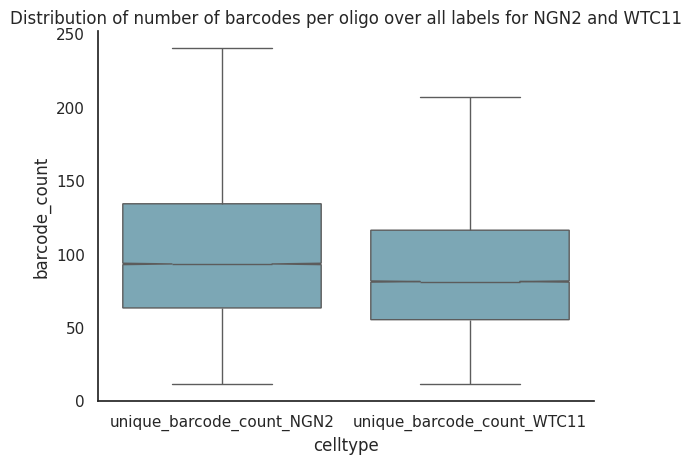

In [ ]:
sns.boxplot(data = NGN2_WTC11_barcode_count_distribution,
               x = 'celltype',
               y = 'barcode_count',
               showfliers=False,
               notch=True)
# TODO: add statistical test to compare mean difference with p-value and add the stars wie z.b.: https://www.researchgate.net/figure/A-box-plot-visualization-including-Mann-Whitney-U-tests-of-the-sarcopenia-and-cardiac_fig3_364058085
plt.title('Distribution of number of barcodes per oligo over all labels for NGN2 and WTC11')
plt.show()

### Ploting the distribution of the normalized effectsize over all labels for the NGN2 and WTC11 celltypes

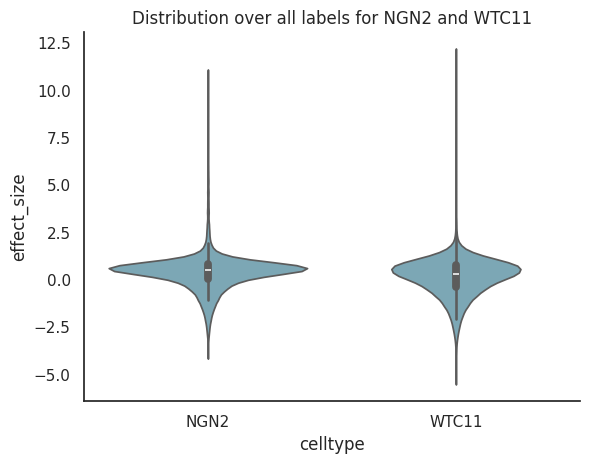

In [ ]:
sns.violinplot(data = NGN2_WTC11_effect_size_distribution,
               x = 'celltype',
               y = 'effect_size')
plt.title('Distribution over all labels for NGN2 and WTC11')
plt.show()

In [ ]:
NGN2_WTC11_effect_size_distribution["abs_effect_size"] = NGN2_WTC11_effect_size_distribution["effect_size"].abs()

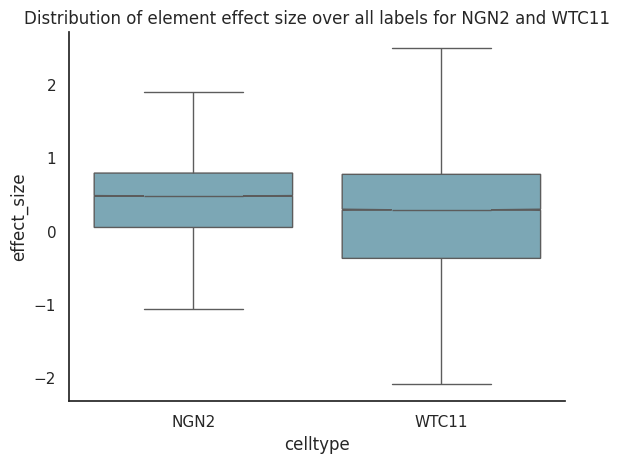

In [ ]:
sns.boxplot(data = NGN2_WTC11_effect_size_distribution,
               x = 'celltype',
               y = 'effect_size',
               showfliers=False,
               notch=True)
plt.title('Distribution of element effect size over all labels for NGN2 and WTC11')
plt.show()

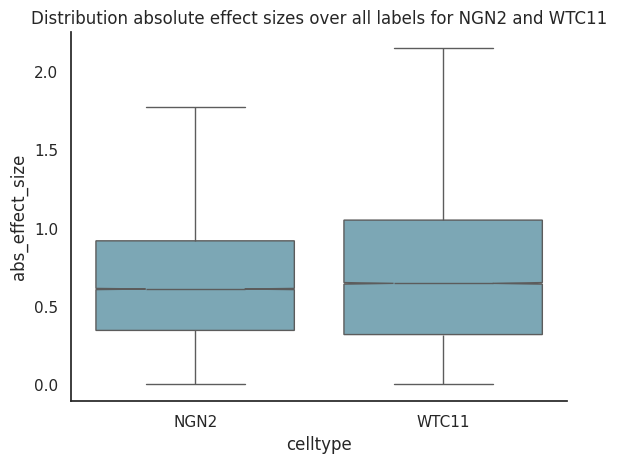

In [ ]:
sns.boxplot(data = NGN2_WTC11_effect_size_distribution,
               x = 'celltype',
               y = 'abs_effect_size',
               showfliers=False,
               notch=True)
plt.title('Distribution absolute effect sizes over all labels for NGN2 and WTC11')
plt.show()

# Scramble_ctrl

#### Create data frames only für the scramble_ctrl labels

In [ ]:
merge_scrambled = NGN2_WTC11_merge[NGN2_WTC11_merge['label'] == 'scramble_ctrl']

### Spearman plot for the effect size of the merged table

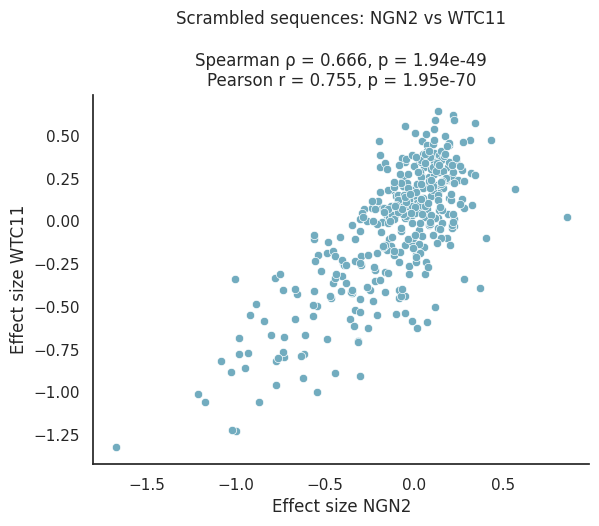

Spearman rho: 0.666, p = 1.935e-49
Pearson r:    0.755, p = 1.954e-70


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

# Spearman correlation
spearman_r, spearman_p = spearmanr(
    merge_scrambled['effect_size_NGN2'],
    merge_scrambled['effect_size_WTC11']
)

# Pearson correlation
pearson_r, pearson_p = pearsonr(
    merge_scrambled['effect_size_NGN2'],
    merge_scrambled['effect_size_WTC11']
)

# Plot
sns.scatterplot(
    data=merge_scrambled,
    x='effect_size_NGN2',
    y='effect_size_WTC11'
)

plt.title(
    f'Scrambled sequences: NGN2 vs WTC11\n\n'
    f'Spearman ρ = {spearman_r:.3f}, p = {spearman_p:.2e}\n'
    f'Pearson r = {pearson_r:.3f}, p = {pearson_p:.2e}'
)

plt.xlabel('Effect size NGN2')
plt.ylabel('Effect size WTC11')

plt.show()

print(f"Spearman rho: {spearman_r:.3f}, p = {spearman_p:.3e}")
print(f"Pearson r:    {pearson_r:.3f}, p = {pearson_p:.3e}")

The effect sizes of scrambled control oligos show a strong positive correlation between NGN2 and WTC11 (Spearman ρ = 0.666, Pearson r = 0.755), with both correlations being highly statistically significant. The slightly higher Pearson correlation is consistent with a strong linear relationship between the effect sizes

### Violin plot to show the distribution of the effect size between the NGN2 and WTC11 cells

In [ ]:
merge_scrambled_long = merge_scrambled.melt(
    id_vars = 'oligo_name',
    value_vars = ['effect_size_NGN2', 'effect_size_WTC11'],
    var_name = 'celltype',
    value_name = 'effect_size'
)
merge_scrambled_long.loc[merge_scrambled_long['celltype'].str.contains('NGN2'), 'celltype'] = 'NGN2'
merge_scrambled_long.loc[merge_scrambled_long['celltype'].str.contains('WTC11'), 'celltype'] = 'WTC11'

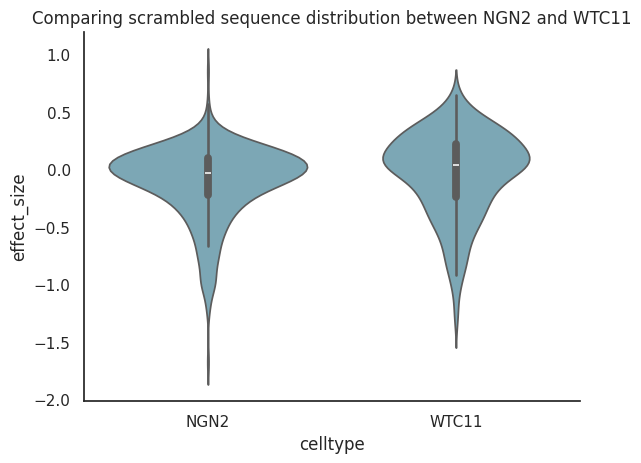

In [ ]:
sns.violinplot(data = merge_scrambled_long,
               x = 'celltype',
               y = 'effect_size',
)
plt.title('Comparing scrambled sequence distribution between NGN2 and WTC11')
plt.show()



# Distribution of unique barcode count in cardiac_neuro_cava for both cell types

#### Filter for cardiac neuro cava random label

In [ ]:
cardiac_merge = NGN2_WTC11_merge[NGN2_WTC11_merge['label'] == 'cardiac_neuro_cava_random'].reset_index(drop = True)

#### Create a long-format data table assigning unique barcode counts to each cell type

In [ ]:
barcode_distribution = cardiac_merge.melt(
    id_vars = 'oligo_name',
    value_vars = ['unique_barcode_count_NGN2', 'unique_barcode_count_WTC11'],
    var_name = 'celltype',
    value_name = 'unique_barcode_count'
)
barcode_distribution.loc[barcode_distribution['celltype'].str.contains('NGN2'), 'celltype'] = 'NGN2'
barcode_distribution.loc[barcode_distribution['celltype'].str.contains('WTC11'), 'celltype'] = 'WTC11'

#### Plot the unique barcode count distribution

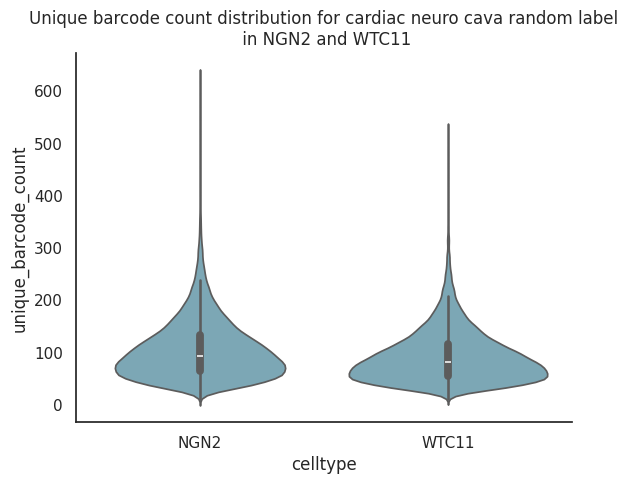

In [ ]:
sns.violinplot(data = barcode_distribution,
               x = 'celltype',
               y = 'unique_barcode_count')
plt.title('Unique barcode count distribution for cardiac neuro cava random label\n in NGN2 and WTC11')
plt.show()

# Scramble_ctrl combined with cardiac_neuro_cava_random

#### Filter for Scramble_ctrl and cardiac neuro cava label

In [ ]:
scramble_cardiac_merge = NGN2_WTC11_merge[NGN2_WTC11_merge['label'].isin(['scramble_ctrl',
                                                                          'cardiac_neuro_cava_random'])]

In [ ]:
scramble_cardiac_distribution = scramble_cardiac_merge.melt(
    id_vars = 'label',
    value_vars = ['norm_effect_size_NGN2', 'norm_effect_size_WTC11'],
    var_name = 'celltype',
    value_name = 'effect_size'
)
scramble_cardiac_distribution.loc[scramble_cardiac_distribution['celltype'].str.contains('NGN2'), 'celltype'] = 'NGN2' 
scramble_cardiac_distribution.loc[scramble_cardiac_distribution['celltype'].str.contains('WTC11'), 'celltype'] = 'WTC11' 

#### Create a violin plot to compare the normalized effect size of both cell types with the scrambled_ctr and cardiac_neuro_cava_random lables

<Axes: xlabel='celltype', ylabel='effect_size'>

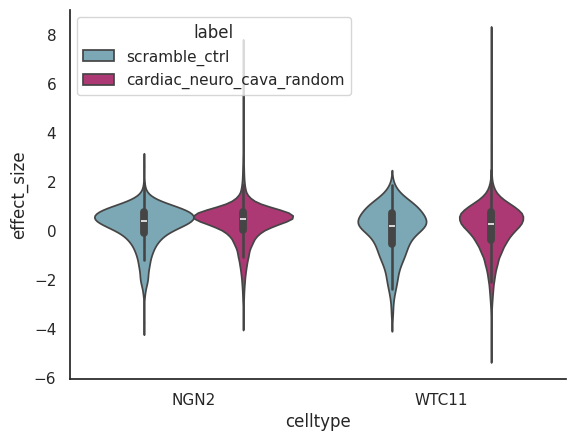

In [ ]:
sns.violinplot(data = scramble_cardiac_distribution,
               x = 'celltype',
               y = 'effect_size',
               hue = 'label')